In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('/mnt/c/Users/scana/Desktop/predicting_f1_pit_stops/train.csv')
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


Column explanation:
- Driver – Driver code
- Compound_Encoded – Tire compound
- Year – Season of the race
- Race – Grand Prix name
- PitStop – Whether the driver pitted on that lap (0/1)
- LapNumber – Lap index within the race
- Stint – Tire stint number
- TyreLife – Number of laps on current tire
- Position – Driver's position on that lap
- LapTime (s) – Lap time in seconds
- LapTime_Delta – Change in lap time from previous lap
- Cumulative_Degradation – Accumulated tire performance drop
- RaceProgress – Fraction of race completed (0 → 1)
- Position_Change – Position gain/loss compared to previous lap

- Normalized_TyreLife (Not included) – Tire life normalized within stint

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,439140.0,219569.500000,126768.942943,0.000000,109784.75000,219569.500000,329354.250000,439139.000
Year,439140.0,2023.523544,1.024930,2022.000000,2023.00000,2024.000000,2024.000000,2025.000
PitStop,439140.0,0.136118,0.342915,0.000000,0.00000,0.000000,0.000000,1.000
LapNumber,439140.0,23.105909,16.958261,1.000000,9.00000,19.000000,36.000000,78.000
Stint,439140.0,1.789113,0.950194,1.000000,1.00000,2.000000,2.000000,8.000
TyreLife,439140.0,14.158231,9.801338,1.000000,6.00000,12.000000,20.000000,77.000
Position,439140.0,9.630339,5.278770,1.000000,5.00000,10.000000,14.000000,20.000
LapTime (s),439140.0,90.948735,19.772769,67.694000,82.62100,90.521000,98.471000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-8.88400,-0.295000,0.115000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-46.56625,-20.994000,-6.199000,2412.026


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [8]:
df.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [17]:
matrix

Compound,HARD,INTERMEDIATE,MEDIUM,SOFT,WET
Driver,,,,,
ALB,506,90,641,102,7
ALE,619,107,583,134,8
ALG,575,117,711,114,10
ALO,511,93,640,136,6
AND,551,75,684,141,10
...,...,...,...,...,...
WIL,501,74,700,109,8
WUR,542,89,651,120,11
YAM,572,100,641,129,13


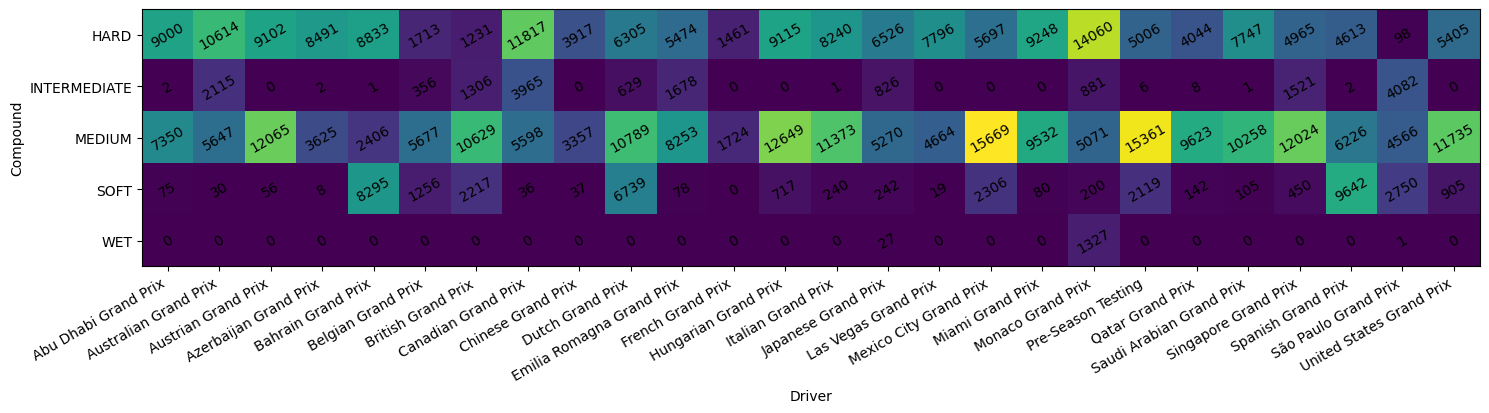

In [25]:
matrix = pd.crosstab(df["Compound"], df["Race"])

fig, ax = plt.subplots(figsize=(15, 6))
im = ax.imshow(matrix)
ax.set_xticks(range(len(matrix.columns)))
ax.set_yticks(range(len(matrix.index)))
ax.set_xticklabels(matrix.columns, ha='right', rotation=30)
ax.set_yticklabels(matrix.index)
ax.set_xlabel("Driver")
ax.set_ylabel("Compound")

# Add counts inside cells
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        ax.text(j, i, matrix.iloc[i, j], ha="center", va="center", rotation=30)

#plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

In [22]:
df_test = pd.read_csv('/mnt/c/Users/scana/Desktop/predicting_f1_pit_stops/test.csv')
df_test.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0
